## Data Collection and Engineering

In [3]:
import pandas as pd
import numpy as np
import os

In [1]:
raw_data_path = "../data/Online Retail.xlsx"

In [4]:
print("Loading raw transactional data (this may take a minute)...")
df_sales = pd.read_excel(raw_data_path)

Loading raw transactional data (this may take a minute)...


In [5]:
print(f"Dataset Shape: {df_sales.shape}")
df_sales.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
np.random.seed(42)

In [7]:
print(f"Total Raw Rows: {df_sales.shape[0]}")
print(f"Missing Customer IDs: {df_sales['CustomerID'].isnull().sum()}")
print(f"Canceled Transactions (Negative Quantities): {df_sales['Quantity'].get(df_sales['Quantity'] < 0, pd.Series()).count()}")

Total Raw Rows: 541909
Missing Customer IDs: 135080
Canceled Transactions (Negative Quantities): 10624


Data Wrangling (Cleaning the Sales Database)

In [9]:
# 1. Drop missing Customer IDs
df_sales = df_sales.dropna(subset=['CustomerID']).copy()
df_sales['CustomerID'] = df_sales['CustomerID'].astype(int)

In [10]:
# 2. Separate standard sales from cancellations
df_cancelled = df_sales[df_sales['Quantity'] < 0].copy()
df_sales = df_sales[df_sales['Quantity'] > 0]

In [11]:
# 3. Clean product strings
df_sales['StockCode'] = df_sales['StockCode'].astype(str).str.strip()
df_sales['Description'] = df_sales['Description'].astype(str).str.strip()

In [12]:
print(f"Cleaned Sales Records: {df_sales.shape[0]}")
print(f"Unique Customers: {df_sales['CustomerID'].nunique()}")
print(f"Unique Products: {df_sales['StockCode'].nunique()}")

Cleaned Sales Records: 397924
Unique Customers: 4339
Unique Products: 3665


Architecting the Multi-Source Clickstream Logs

In [13]:
print("Synthesizing web clickstream logs based on user purchasing behavior...")

Synthesizing web clickstream logs based on user purchasing behavior...


In [14]:
clickstream_records = []
session_counter = 100001

In [15]:
# Group transactions by Customer and Invoice to simulate unique browsing sessions
for (customer_id, invoice_no), group in df_sales.groupby(['CustomerID', 'InvoiceNo']):
    # Assume a session started roughly 15 to 45 minutes before the actual invoice timestamp
    base_time = group['InvoiceDate'].min()
    
    # Generate random session properties for User Engagement Metrics
    session_id = f"SESS_{session_counter}"
    session_counter += 1
    
    # Track items that were actually bought in this session
    purchased_items = group['StockCode'].unique()
    
    # Simulate browsing steps before purchasing
    for item in purchased_items:
        # User clicks the item
        click_time = base_time - pd.Timedelta(minutes=np.random.randint(10, 30))
        clickstream_records.append({
            'SessionID': session_id,
            'CustomerID': customer_id,
            'Timestamp': click_time,
            'EventType': 'click',
            'ProductID': item
        })
        
        # User adds the item to the cart
        cart_time = base_time - pd.Timedelta(minutes=np.random.randint(2, 9))
        clickstream_records.append({
            'SessionID': session_id,
            'CustomerID': customer_id,
            'Timestamp': cart_time,
            'EventType': 'add_to_cart',
            'ProductID': item
        })
        
    # Introduce some noise: items they clicked but DID NOT buy (Crucial for predictive modeling!)
    random_products = df_sales['StockCode'].sample(np.random.randint(1, 4)).values
    for random_item in random_products:
        noise_time = base_time - pd.Timedelta(minutes=np.random.randint(5, 25))
        clickstream_records.append({
            'SessionID': session_id,
            'CustomerID': customer_id,
            'Timestamp': noise_time,
            'EventType': 'click',
            'ProductID': random_item
        })

# Create the Clickstream Dataframe
df_clickstream = pd.DataFrame(clickstream_records)
print(f"Generated Clickstream Log Database with {df_clickstream.shape[0]} tracking events.")

Generated Clickstream Log Database with 812807 tracking events.


Engineering User Engagement Profiles

In [16]:
unique_sessions = df_clickstream['SessionID'].unique()

engagement_records = []
devices = ['Mobile_iOS', 'Mobile_Android', 'Desktop_Chrome', 'Desktop_Safari']
channels = ['Google_SEO', 'Meta_Ads', 'Direct_Traffic', 'Newsletter']

for session in unique_sessions:
    engagement_records.append({
        'SessionID': session,
        'DeviceType': np.random.choice(devices, p=[0.4, 0.3, 0.2, 0.1]),
        'TrafficSource': np.random.choice(channels, p=[0.35, 0.25, 0.20, 0.20]),
        'TotalSessionTime_Min': round(np.random.uniform(5.5, 45.0), 2)
    })

df_engagement = pd.DataFrame(engagement_records)
print(f"Generated User Engagement Metrics for {df_engagement.shape[0]} sessions.")

Generated User Engagement Metrics for 18536 sessions.


Save Our Infrastructure Databases

In [17]:
# Save clean states to data folder
df_sales.to_csv('../data/sales_history.csv', index=False)
df_clickstream.to_csv('../data/clickstream_logs.csv', index=False)
df_engagement.to_csv('../data/user_engagement.csv', index=False)

print("All source data engines pipeline optimized and saved successfully to /data folder!")

All source data engines pipeline optimized and saved successfully to /data folder!


## Exploratory Data Analysis (EDA)

In [18]:
# 1. Total events by type
event_counts = df_clickstream['EventType'].value_counts()
print("--- Event Type Breakdown ---")
print(event_counts)
print("\n")

# 2. Calculate Click-to-Cart Conversion Rate
clicks = event_counts.get('click', 0)
carts = event_counts.get('add_to_cart', 0)
purchases = df_sales['InvoiceNo'].nunique()

print("--- Core E-Commerce Funnel Analytics ---")
print(f"Total Clicks (Product Views): {clicks}")
print(f"Total Adds to Cart: {carts}")
print(f"Total Completed Purchases (Invoices): {purchases}")
print(f"Product View to Cart Conversion Rate: {(carts / clicks) * 100:.2f}%")

--- Event Type Breakdown ---
EventType
click          424932
add_to_cart    387875
Name: count, dtype: int64


--- Core E-Commerce Funnel Analytics ---
Total Clicks (Product Views): 424932
Total Adds to Cart: 387875
Total Completed Purchases (Invoices): 18536
Product View to Cart Conversion Rate: 91.28%


In [19]:
# Merge clickstream with engagement profiles to analyze traffic patterns
df_session_behavior = pd.merge(df_clickstream, df_engagement, on='SessionID', how='inner')

# Calculate average session length and interaction density by traffic acquisition source
channel_analysis = df_session_behavior.groupby('TrafficSource').agg(
    Total_Events=('EventType', 'count'),
    Avg_Session_Duration=('TotalSessionTime_Min', 'mean')
).reset_index()

print("--- User Engagement Analysis by Acquisition Channel ---")
print(channel_analysis)

--- User Engagement Analysis by Acquisition Channel ---
    TrafficSource  Total_Events  Avg_Session_Duration
0  Direct_Traffic        161000             25.236590
1      Google_SEO        277306             25.395785
2        Meta_Ads        205960             25.744995
3      Newsletter        168541             25.114476


C:\Users\anish\AppData\Local\Temp\ipykernel_12884\3416279722.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Volume', y='Stage', data=funnel_data, palette='Blues_r')


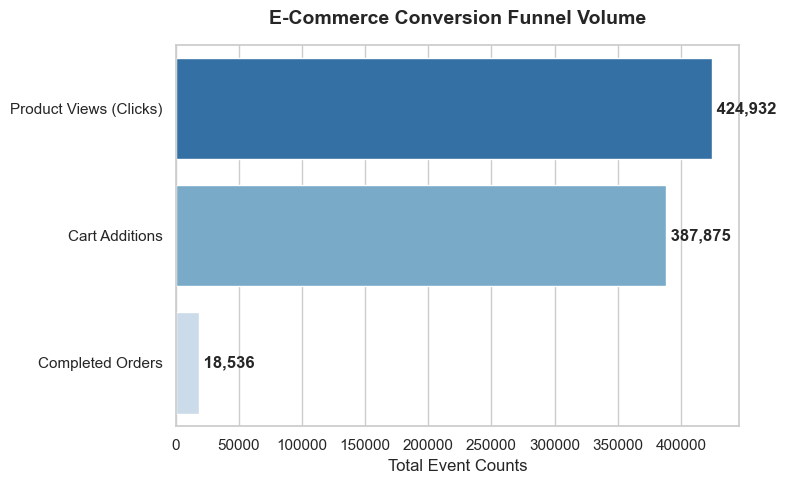

C:\Users\anish\AppData\Local\Temp\ipykernel_12884\3416279722.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TrafficSource', y='TotalSessionTime_Min', data=df_engagement, palette='Set2')


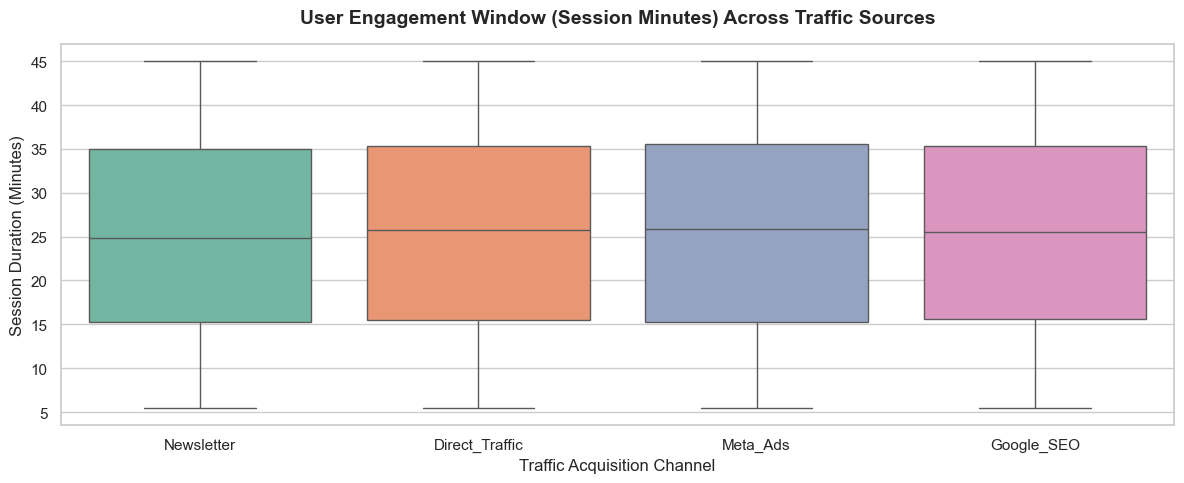

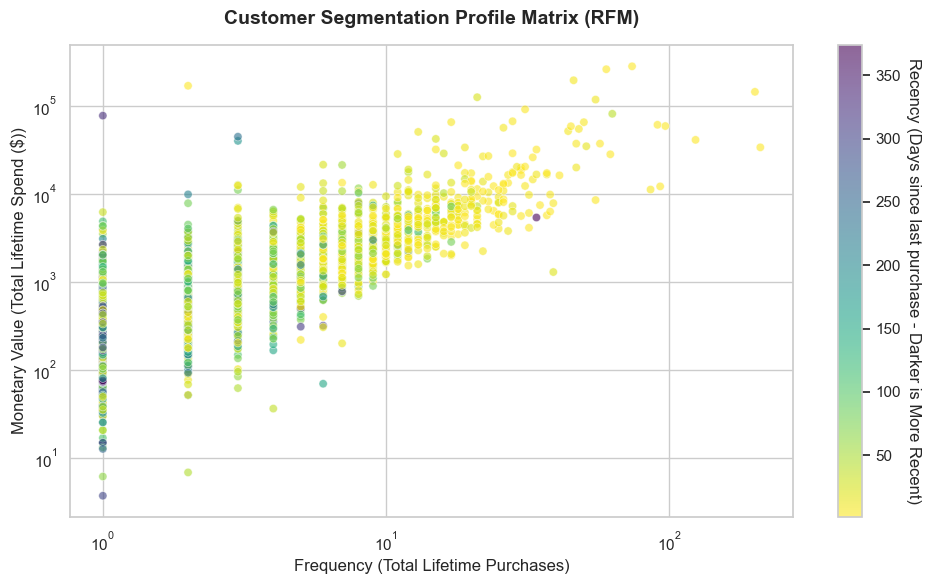

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plotting style for enterprise reporting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# 1. Visualization 1: E-Commerce Funnel Conversion Drop-off
plt.figure(figsize=(8, 5))
funnel_data = pd.DataFrame({
    'Stage': ['Product Views (Clicks)', 'Cart Additions', 'Completed Orders'],
    'Volume': [clicks, carts, purchases]
})
sns.barplot(x='Volume', y='Stage', data=funnel_data, palette='Blues_r')
plt.title('E-Commerce Conversion Funnel Volume', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Event Counts')
plt.ylabel('')
for index, value in enumerate(funnel_data['Volume']):
    plt.text(value, index, f' {value:,}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Visualization 2: Distribution of Session Times by Traffic Channel
plt.figure(figsize=(12, 5))
sns.boxplot(x='TrafficSource', y='TotalSessionTime_Min', data=df_engagement, palette='Set2')
plt.title('User Engagement Window (Session Minutes) Across Traffic Sources', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Traffic Acquisition Channel')
plt.ylabel('Session Duration (Minutes)')
plt.tight_layout()
plt.show()

# 3. Visualization 3: Identifying High-Value Customers via RFM Scatter Distribution
plt.figure(figsize=(10, 6))
# We take log transforms of variables if highly skewed to make visuals scannable
scatter = plt.scatter(
    df_rfm['Frequency_Purchases'], 
    df_rfm['Monetary_Value'], 
    c=df_rfm['Recency_Days'], 
    cmap='viridis_r', 
    alpha=0.6, 
    edgecolors='w', 
    linewidth=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Recency (Days since last purchase - Darker is More Recent)', rotation=270, labelpad=15)
plt.title('Customer Segmentation Profile Matrix (RFM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Total Lifetime Purchases)')
plt.ylabel('Monetary Value (Total Lifetime Spend ($))')
plt.xscale('log') # Log scale handles extreme outlier wholesale buyers gracefully
plt.yscale('log')
plt.tight_layout()
plt.show()

## Automated Feature Engineering (RFM Profiles)

In [20]:
print("Engineering lifetime user behavioral vectors (RFM Features)...")

# 1. Calculate total spending per transaction line item
df_sales['LineTotal'] = df_sales['Quantity'] * df_sales['UnitPrice']

# 2. Set our anchor snapshot date (simulating 'today' as the day after the last invoice in the dataset)
snapshot_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

# 3. Aggregate metrics per unique customer ID
df_rfm = df_sales.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'LineTotal': 'sum'                                       # Monetary
}).reset_index()

# Rename columns to clear business attributes
df_rfm.columns = ['CustomerID', 'Recency_Days', 'Frequency_Purchases', 'Monetary_Value']

print(f"Engineered user profiles for {df_rfm.shape[0]} unique enterprise accounts.")
df_rfm.head()

Engineering lifetime user behavioral vectors (RFM Features)...
Engineered user profiles for 4339 unique enterprise accounts.


,CustomerID,Recency_Days,Frequency_Purchases,Monetary_Value
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
